In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"])
df.head()

,,Название,Цена,Дата,Тип автора,Метро/Район,Адрес,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,
320731003,cian.ru,"Офис в Москва Шипиловская ул., 58к1 (25 м²)",38800,2025-08-23 02:23:27,Агентство,Шипиловская,"Шипиловская ул., 58к1",55.621211,37.745600,https://www.cian.ru/rent/commercial/320731003,['https://images.cdn-cian.ru/images/2592583348...,0.083,4.0,6.0,Офисное помещение,25.0
321876001,cian.ru,"Офис в Москва Ленинградский просп., 47С2 (25 м²)",31250,2025-09-25 20:21:36,Агентство,Аэропорт,"Ленинградский просп., 47С2",55.799036,37.532601,https://www.cian.ru/rent/commercial/321876001,['https://images.cdn-cian.ru/images/2631122267...,0.250,-2.0,7.0,Офисное помещение,25.0
322186790,cian.ru,"Офис в Москва Волгоградский просп., 2 (20 м²)",29200,2025-09-25 10:22:06,Агентство,Пролетарская,"Волгоградский просп., 2",55.731176,37.669279,https://www.cian.ru/rent/commercial/322186790,['https://images.cdn-cian.ru/images/2641248288...,0.250,6.0,16.0,Офисное помещение,20.0
321392086,cian.ru,Помещение свободного назначения в Москва ул. А...,32000,2025-09-02 04:23:10,Частное лицо,Бунинская Аллея,"ул. Адмирала Руднева, 20",55.540409,37.516153,https://www.cian.ru/rent/commercial/321392086,['https://images.cdn-cian.ru/images/nezhiloe-p...,0.250,3.0,7.0,Торговое / Свободного назначения,32.0
324943206,cian.ru,"Офис в Москва просп. Мира, 95С1 (24 м²)",44000,2025-12-11 16:28:22,Агентство,Алексеевская,"просп. Мира, 95С1",55.808002,37.635853,https://www.cian.ru/rent/commercial/324943206,['https://images.cdn-cian.ru/images/ofis-moskv...,0.167,14.0,17.0,Офисное помещение,24.0


In [3]:
df.dtypes

Название                           object
Цена                                int64
Дата                       datetime64[ns]
Тип автора                         object
Метро/Район                        object
Адрес                              object
lat                               float64
lng                               float64
URL                                object
Ссылки на картинки                 object
Расстояние до метро, км           float64
Этаж                              float64
Этажность здания                  float64
Вид объекта                        object
Общая площадь                     float64
dtype: object

In [4]:
df.columns

Index(['Название', 'Цена', 'Дата', 'Тип автора', 'Метро/Район', 'Адрес', 'lat',
       'lng', 'URL', 'Ссылки на картинки', 'Расстояние до метро, км', 'Этаж',
       'Этажность здания', 'Вид объекта', 'Общая площадь'],
      dtype='object')

In [5]:
df.isna().sum()

Название                     0
Цена                         0
Дата                         0
Тип автора                   0
Метро/Район                  0
Адрес                        4
lat                          0
lng                          0
URL                          0
Ссылки на картинки         148
Расстояние до метро, км      0
Этаж                       123
Этажность здания           128
Вид объекта                  1
Общая площадь                0
dtype: int64

In [6]:
df = df.dropna(subset="Вид объекта")

In [7]:
df["Метро/Район"].nunique()

315

# Трансформации

**Hack:** `OrdinalEncoder` нам создает некий ненужный порядок, которого у нас нет. Однако его можно ввести: достаточно понять влияние той или иной категории на таргет. Условно, делаем `TargetEncoding` -- назначаем метки по мере возрастания значения (дополнительно еще зашумляем и сглаживает). Так мы избегаем и сильной утечки таргета, и сохраняем важные данные.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder


class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=10)

    def fit(self, X, y):
        self.te = self.te.fit(X, y)
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            ordinal_mapping = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            X_copy[col] = X_copy[col].map(ordinal_mapping)
            X_copy[col] = X_copy[col].fillna(len(ordinal_categories) // 2)
        return X_copy

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def set_output(self, *, transform=None):
        """Scikit-learn 1.2+ requirement"""
        return self

In [9]:
data = pd.read_csv("geo_data.csv")
data = data.dropna(subset=["lat", "lon", "rubrics"])

In [10]:
from collections import Counter

data["rub_list"] = (
    data["rubrics"]
        .astype(str)
        .str.split(";")
        .apply(lambda x: [s.strip() for s in x if s.strip()])
)

all_rubrics = Counter(x for lst in data["rub_list"] for x in lst)
keep_rubrics = {k for k, v in all_rubrics.items() if v >= 60}


In [11]:
from sklearn.neighbors import BallTree

EARTH_R = 6371000.0

coords_data = np.radians(data[["lat", "lon"]].values)
tree = BallTree(coords_data, metric  = "haversine")

def get_lst(lat, lon, R_m):
    idxs = tree.query_radius(np.radians([[lat, lon]]), r = R_m / EARTH_R)[0]
    lst = {}
    for i in idxs:
        for r in data.iloc[i]["rub_list"]:
            if r in keep_rubrics:
                lst[r] = lst.get(r, 0) + 1
    return lst

R = 600

geo = []
for i, row in df.iterrows():
    geo.append(get_lst(row["lat"], row["lng"], R))

geo_df = pd.DataFrame(geo).fillna(0).astype(int)
geo_df.columns = [f"cnt_{c.replace(' ', '_')}" for c in geo_df.columns]
geo_cols = geo_df.columns.tolist()

df = pd.concat([df.reset_index(drop=True), geo_df.reset_index(drop=True)], axis=1)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, # OrdinalEncoder, TargetEncoder,
    StandardScaler, # MinMaxScaler, RobustScaler,
)

from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(),["Общая площадь", "Расстояние до метро, км", "Этаж"] + geo_cols),
        ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), ["Вид объекта", "Тип автора"]),
        ("ordinal", OrdinalByTargetEncoder(), ["Метро/Район"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

In [13]:
from sklearn.model_selection import train_test_split

X = df[
    ["Общая площадь", "Расстояние до метро, км", "Этаж"]
    + geo_cols
    + ["Вид объекта", "Тип автора", "Метро/Район"]
].copy()

y = df["Цена"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [14]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Офисное помещение                   66.769593
Торговое / Свободного назначения    32.112925
Здание                               1.117483
Name: count, dtype: float64

In [15]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Офисное помещение                   66.754850
Торговое / Свободного назначения    32.098765
Здание                               1.146384
Name: count, dtype: float64

In [16]:
X_train.isna().sum()

Общая площадь                 0
Расстояние до метро, км       0
Этаж                         90
cnt_Детский_сад,_ясли         0
cnt_Магазин_пива              0
                             ..
cnt_Кузовной_ремонт           0
cnt_Больница_для_взрослых     0
Вид объекта                   0
Тип автора                    0
Метро/Район                   0
Length: 153, dtype: int64

In [17]:
X_test.isna().sum()

Общая площадь                 0
Расстояние до метро, км       0
Этаж                         33
cnt_Детский_сад,_ясли         0
cnt_Магазин_пива              0
                             ..
cnt_Кузовной_ремонт           0
cnt_Больница_для_взрослых     0
Вид объекта                   0
Тип автора                    0
Метро/Район                   0
Length: 153, dtype: int64

In [18]:
floor_mode = X_train["Этаж"].mode().values[0]
X_train["Этаж"] = X_train["Этаж"].fillna(floor_mode)
X_test["Этаж"] = X_test["Этаж"].fillna(floor_mode)

In [19]:
ct = ct.fit(X_train, y_train)
X_train_base = ct.transform(X_train)
X_test_base = ct.transform(X_test)

X_train_base

,scale__Общая площадь,"scale__Расстояние до метро, км",scale__Этаж,"scale__cnt_Детский_сад,_ясли",scale__cnt_Магазин_пива,scale__cnt_Доставка_цветов_и_букетов,scale__cnt_Магазин_цветов,scale__cnt_Салон_красоты,scale__cnt_Массажный_салон,scale__cnt_Обучение_мастеров_для_салонов_красоты,...,scale__cnt_Парк_культуры_и_отдыха,scale__cnt_Православный_храм,scale__cnt_Курьерские_услуги,scale__cnt_Кузовной_ремонт,scale__cnt_Больница_для_взрослых,onehot__Вид объекта_Здание,onehot__Вид объекта_Офисное помещение,onehot__Вид объекта_Торговое / Свободного назначения,onehot__Тип автора_Частное лицо,ordinal__Метро/Район
5221,-0.080518,-0.129277,0.116376,1.267390,-0.451802,-0.643144,1.007792,-0.103886,-0.681565,-0.460255,...,-0.364276,0.783720,2.153889,-0.319943,-0.247378,0.0,1.0,0.0,0.0,205
7773,1.346411,-0.096222,0.678599,1.267390,-0.451802,-0.643144,-0.662691,-0.663141,-0.681565,-0.460255,...,-0.364276,-0.496626,-0.388388,-0.319943,-0.247378,0.0,1.0,0.0,0.0,148
4599,-0.639442,-0.427963,0.959711,-0.520521,1.769967,-0.643144,0.172550,1.014625,2.320587,0.739053,...,-0.364276,-0.496626,2.153889,-0.319943,-0.247378,0.0,1.0,0.0,0.0,240
6648,-0.023853,-0.129277,-0.445848,1.267390,1.769967,-0.643144,1.007792,0.641788,0.319152,1.938361,...,4.888251,0.783720,-0.388388,-0.319943,-0.247378,0.0,0.0,1.0,0.0,227
8008,1.810034,-0.195784,-0.445848,-0.520521,-0.451802,-0.643144,-0.662691,-0.849559,-0.681565,-0.460255,...,-0.364276,-0.496626,-0.388388,-0.319943,-0.247378,0.0,1.0,0.0,0.0,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3087,-0.634291,-0.228839,-0.024180,1.267390,-0.451802,0.525131,0.172550,-0.476722,0.819511,0.739053,...,-0.364276,-0.496626,-0.388388,-0.319943,-0.247378,0.0,1.0,0.0,0.0,262
1110,-0.796816,0.202465,-0.445848,-0.520521,-0.451802,-0.643144,-0.662691,-0.849559,-0.681565,-0.460255,...,-0.364276,-0.496626,-0.388388,-0.319943,-0.247378,0.0,0.0,1.0,0.0,44
5172,-0.170667,-0.228839,0.538043,-0.520521,-0.451802,-0.643144,-0.662691,-0.849559,-0.681565,-0.460255,...,-0.364276,-0.496626,-0.388388,-0.319943,-0.247378,0.0,1.0,0.0,0.0,234
7437,0.269775,-0.394909,-0.445848,1.267390,1.769967,2.861682,1.843033,1.201043,-0.181206,0.739053,...,-0.364276,0.783720,-0.388388,-0.319943,-0.247378,0.0,0.0,1.0,0.0,231


# Модель

In [20]:
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"\t  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"\tRMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"\tMAPE: {mape(y_true, y_pred) * 100:.2f}%")

In [21]:
import sys

sys.path.append("..")

import viz

## Линейка

train metrics:
	  R2: 77.36%
	RMSE: 684027.81 руб.
	MAPE: 91.63%

test metrics:
	  R2: 76.92%
	RMSE: 690300.70 руб.
	MAPE: 105.40%


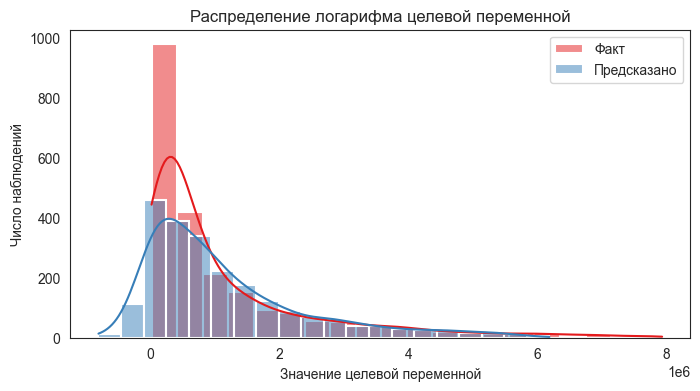

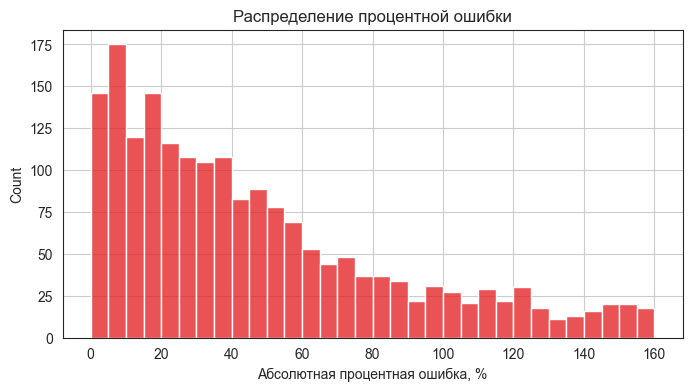

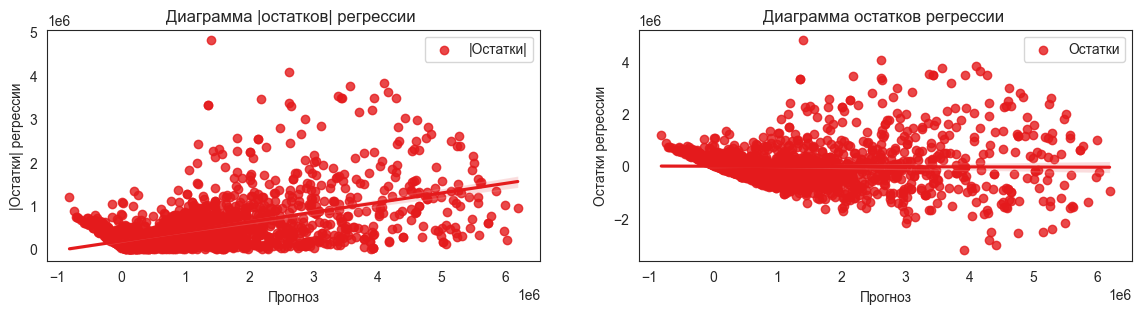

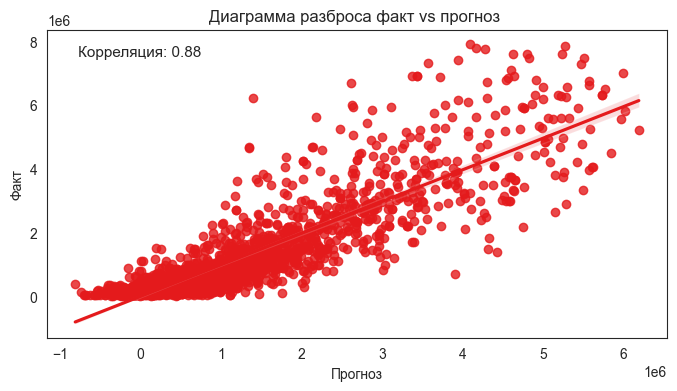

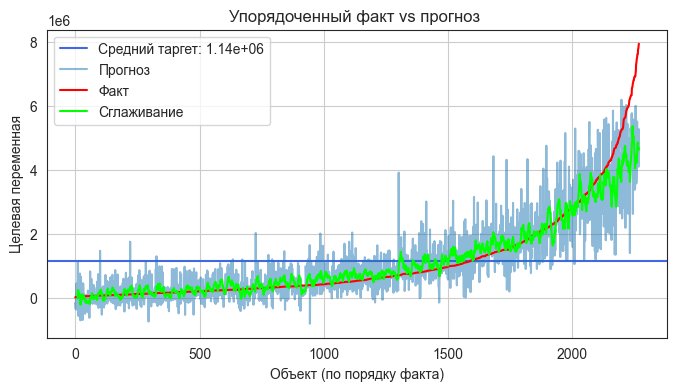

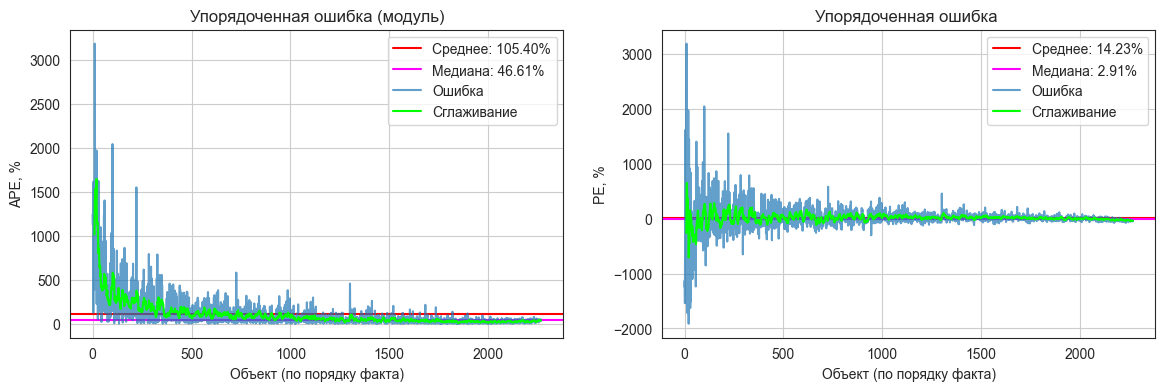

In [22]:
model = LinearRegression().fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

In [23]:
!pip install -q optuna

In [24]:
# import optuna
# from sklearn.model_selection import KFold
# from sklearn.model_selection import cross_validate
# optuna.logging.set_verbosity(optuna.logging.WARNING)


# FIXED_KWARGS = {
#     'tol': 1e-5,
#     'random_state': 42,
# }

# CV = KFold(n_splits=5, random_state=10, shuffle=True)

# def objective(trial, X, y):
#     params = {
#         'alpha': trial.suggest_float('alpha', low=0.0001, high=50),
#         'max_iter': trial.suggest_int('max_iter', low=500, high=3000),
#         'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
#     }
    
#     params.update(FIXED_KWARGS)
#     model = Ridge(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()


# def study_results(study):
#     trial = study.best_trial
#     print('Best CV={} score: {:.6}'.format(CV, trial.value))
#     print('Best params:')
#     for key, value in trial.params.items():
#         print("    {}: {}".format(key, value))


# def plot_study(study):
#     fig_list = [
#         optuna.visualization.plot_optimization_history(study),
#         optuna.visualization.plot_param_importances(study),
#     ]
#     for fig in fig_list:
#         fig.update_layout(width=900)
#         fig.show()

In [25]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_base, y_train),
#                   n_trials=1000, timeout=60, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# if len(study.trials) > 1:
#     plot_study(study)

train metrics:
	  R2: 77.36%
	RMSE: 684027.81 руб.
	MAPE: 91.63%

test metrics:
	  R2: 76.92%
	RMSE: 690284.85 руб.
	MAPE: 105.35%


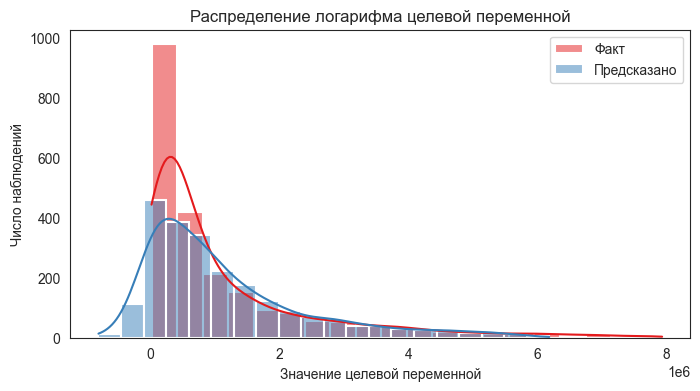

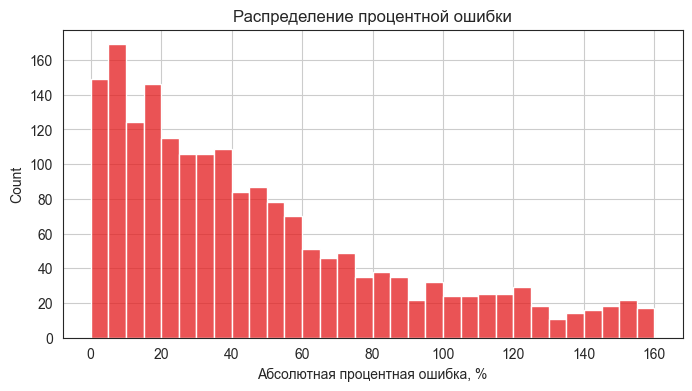

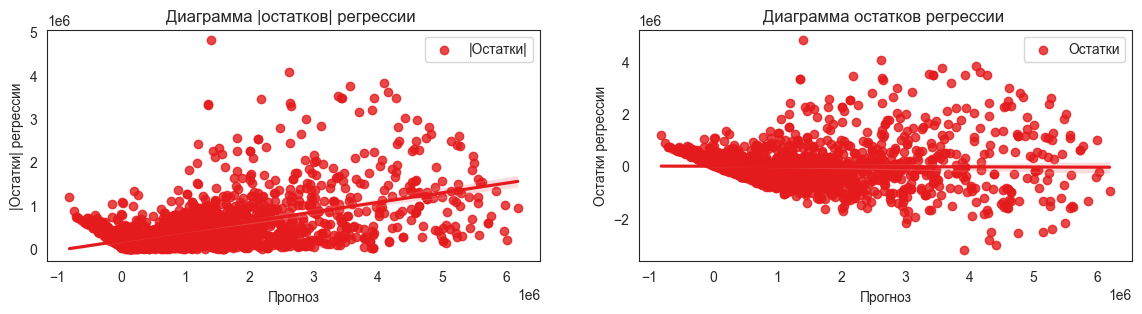

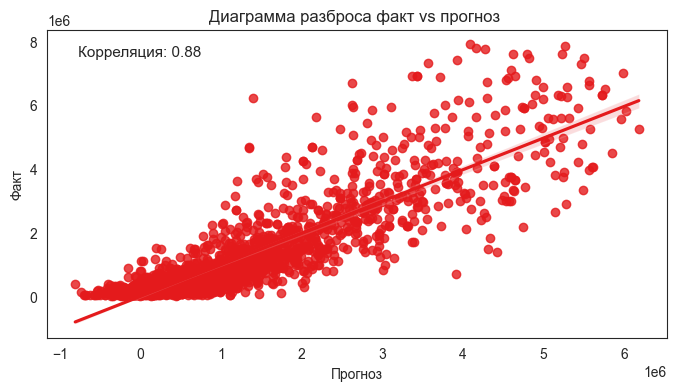

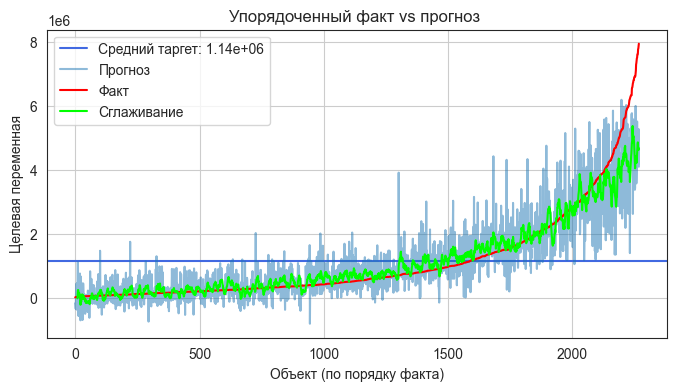

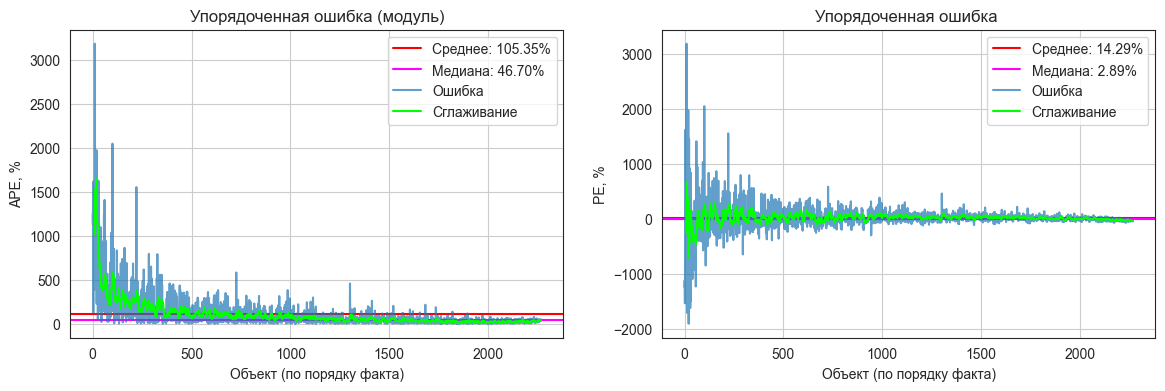

In [26]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

model = Ridge().fit(X_train_base, y_train)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

viz.plot_target_hist(y_test, y_test_pred)
viz.plot_ape_bins(y_test, y_test_pred)
viz.plot_regression_residuals(y_test, y_test_pred)
viz.plot_scatter(y_test, y_test_pred)
viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)

## CatBoost

In [27]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_base, y_train)
y_pred = model.predict(X_train_base)
y_test_pred = model.predict(X_test_base)

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

train metrics:
	  R2: 95.98%
	RMSE: 288435.06 руб.
	MAPE: 29.10%

test metrics:
	  R2: 89.54%
	RMSE: 464636.28 руб.
	MAPE: 38.04%


In [28]:
!pip install shap

In [29]:
import shap

explainer = shap.TreeExplainer(model)

N_SAMPLE = 5000
if X_train_base.shape[0] > N_SAMPLE:
    X_shap = X_train_base.sample(N_SAMPLE, random_state=42)
else:
    X_shap = X_train_base

shap_values = explainer.shap_values(X_shap)
shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
shap_imp

C:\Users\timof\miniconda3\envs\sirius\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scale__Общая площадь              909896.261045
ordinal__Метро/Район              153079.853661
scale__cnt_Кофейня                 53909.720965
scale__Этаж                        50301.763231
scale__cnt_Ресторан                25609.618757
                                      ...      
scale__cnt_Ноутбуки_и_планшеты       328.569720
scale__cnt_Мебель_на_заказ           280.464001
scale__cnt_Курьерские_услуги         199.619617
scale__cnt_Копировальный_центр        86.621337
scale__cnt_Суши-бар                   16.452283
Length: 155, dtype: float64

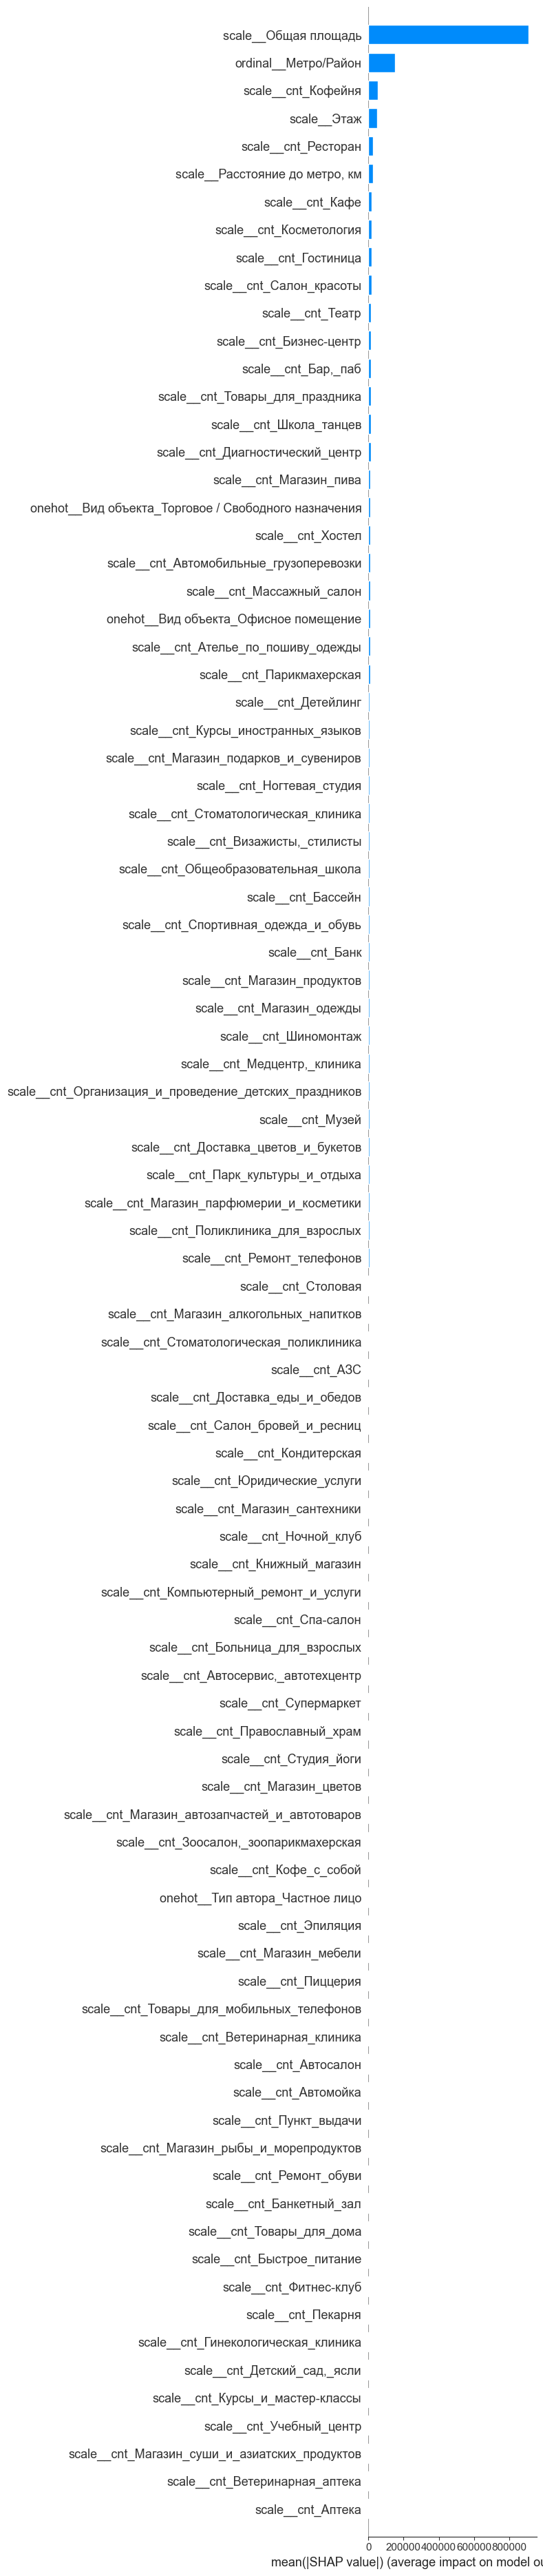

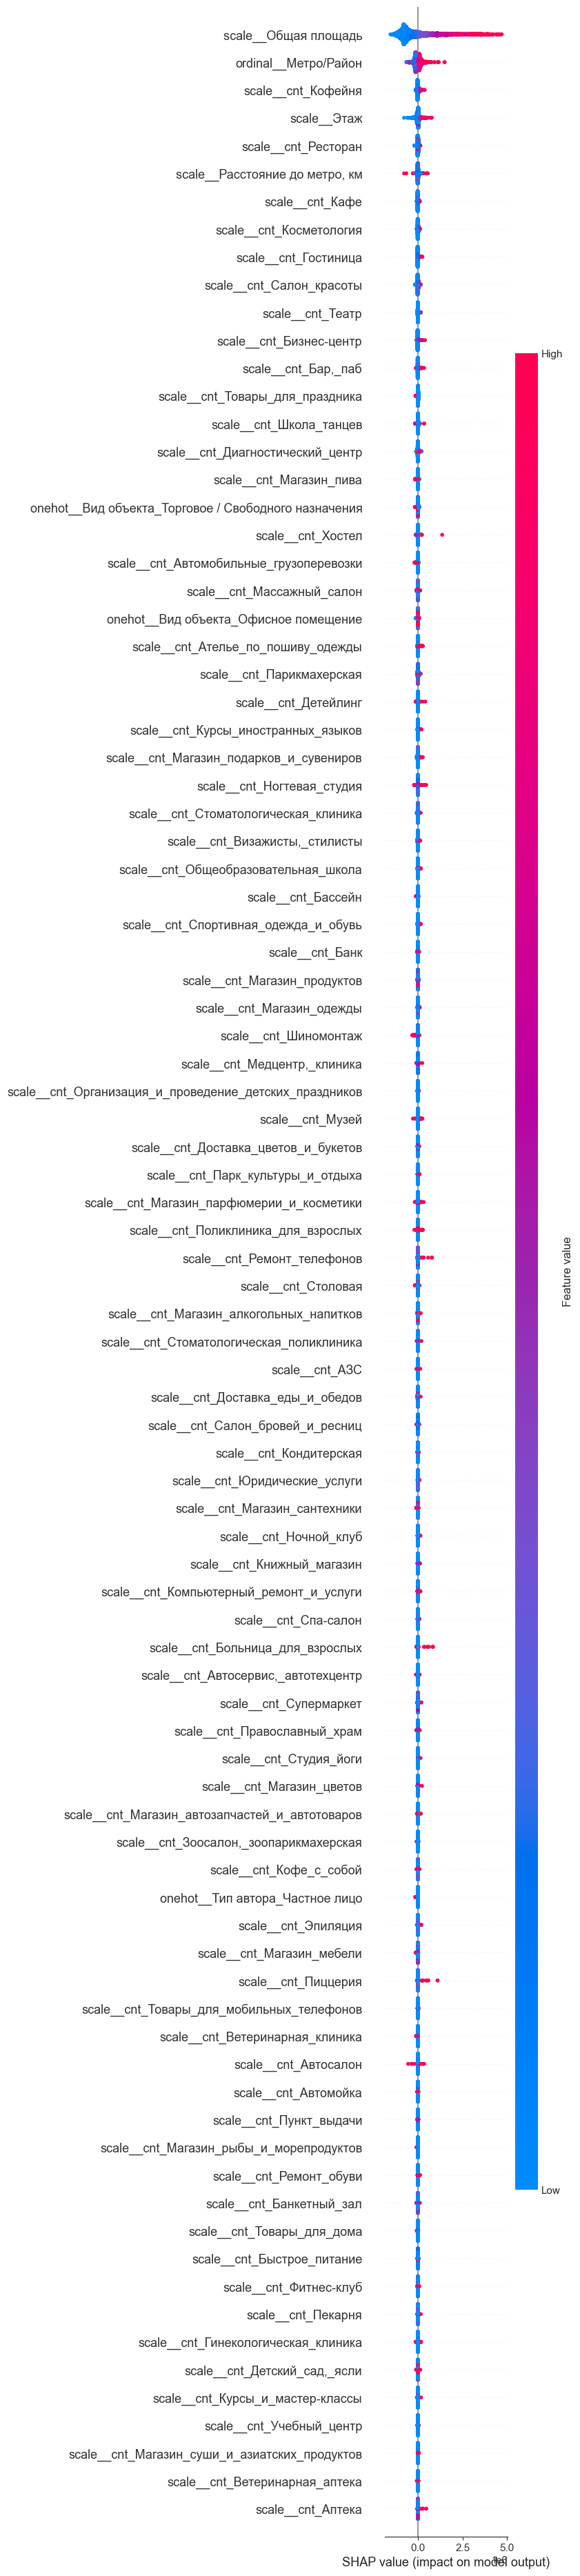

In [30]:
# 6) Диаграммы
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=90)
shap.summary_plot(shap_values, X_shap, plot_type="dot", max_display=90)

In [31]:
n = 10
top_n_features = shap_imp.head(n).index.tolist()
print("Top", n, "features:", top_n_features)

X_train_top = X_train_base[top_n_features]
X_test_top  = X_test_base[top_n_features]

from catboost import CatBoostRegressor

model_top = CatBoostRegressor(verbose=False)
model_top.fit(X_train_top, y_train)

y_pred_train = model_top.predict(X_train_top)
y_pred_test  = model_top.predict(X_test_top)

print_metrics(y_train, y_pred_train, "train")
print()
print_metrics(y_test, y_pred_test, "test")

Top 50 features: ['scale__Общая площадь', 'ordinal__Метро/Район', 'scale__cnt_Кофейня', 'scale__Этаж', 'scale__cnt_Ресторан', 'scale__Расстояние до метро, км', 'scale__cnt_Кафе', 'scale__cnt_Косметология', 'scale__cnt_Гостиница', 'scale__cnt_Салон_красоты', 'scale__cnt_Театр', 'scale__cnt_Бизнес-центр', 'scale__cnt_Бар,_паб', 'scale__cnt_Товары_для_праздника', 'scale__cnt_Школа_танцев', 'scale__cnt_Диагностический_центр', 'scale__cnt_Магазин_пива', 'onehot__Вид объекта_Торговое / Свободного назначения', 'scale__cnt_Хостел', 'scale__cnt_Автомобильные_грузоперевозки', 'scale__cnt_Массажный_салон', 'onehot__Вид объекта_Офисное помещение', 'scale__cnt_Ателье_по_пошиву_одежды', 'scale__cnt_Парикмахерская', 'scale__cnt_Детейлинг', 'scale__cnt_Курсы_иностранных_языков', 'scale__cnt_Магазин_подарков_и_сувениров', 'scale__cnt_Ногтевая_студия', 'scale__cnt_Стоматологическая_клиника', 'scale__cnt_Визажисты,_стилисты', 'scale__cnt_Общеобразовательная_школа', 'scale__cnt_Бассейн', 'scale__cnt_Спорт

In [32]:
# FIXED_KWARGS = {
#     'logging_level': 'Silent',
#     'loss_function': 'RMSE',
#     'random_state': 10,
# }

# def objective(trial, X, y):
#     params = {
#         'iterations': trial.suggest_categorical('iterations', [50, 100, 200, 300, 500, 750, 1000]),
#         'depth': trial.suggest_int('depth', low=3, high=6),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', low=1e-6, high=100.0, log=True),
#         'learning_rate': trial.suggest_float('learning_rate', low=1e-4, high=5e-1), # log=True
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', low=5, high=25),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
#         'subsample': trial.suggest_float('subsample', low=0.3, high=1.0),
#         'early_stopping_rounds': 200,
#     }
    
#     params.update(FIXED_KWARGS)
#     model = CatBoostRegressor(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()

In [33]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_base, y_train),
#                   n_trials=1000, timeout=600, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [34]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = CatBoostRegressor(**params).fit(X_train_base, y_train)
# y_pred = model.predict(X_train_base)
# y_test_pred = model.predict(X_test_base)

# print_metrics(y_train, y_pred, "train")
# print()
# print_metrics(y_test, y_test_pred, "test")

# viz.plot_target_hist(y_test, y_test_pred)
# viz.plot_ape_bins(y_test, y_test_pred)
# viz.plot_regression_residuals(y_test, y_test_pred)
# viz.plot_scatter(y_test, y_test_pred)
# viz.plot_predict_sorted(y_test.values, y_test_pred, window=10)
# viz.plot_ape_sorted(y_test.values, y_test_pred, window=10)